In [7]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Fonction de normalisation classique (Z-score)
def normalize(X):
    m_mean = X.mean(axis=0)
    m_std = X.std(axis=0)
    return (X - m_mean) / m_std

In [9]:
# Chargement du dataset
data=pd.read_csv("../datasets/server_downtime_dataset_20000.csv")

# Sélection des 4 variables explicatives et conversion directe en tenseurs PyTorch
# On précise dtype=torch.float (qui équivaut à float32), le standard habituel pour PyTorch
X=torch.tensor(normalize(data[["Downtime_Minutes","Users_Affected","Transactions","Data_Risk_Transactions_Lost"]].values), dtype=torch.float)
Y=torch.tensor(normalize(data[["Financial_Loss_INR"]].values), dtype=torch.float)

In [10]:
# Définition du modèle : on a 4 caractéristiques en entrée et 1 valeur à prédire en sortie

model=torch.nn.Linear(in_features=4,out_features=1,dtype=torch.float)

# On garde l'Erreur Quadratique Moyenne (MSE) pour la perte et la descente de gradient classique (SGD)
criterion=torch.nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

In [11]:
losses = []

# La boucle d'entraînement standard de PyTorch

for epoch in range(2000):
    # 1: On réinitialise les gradients à zéro pour ne pas accumuler ceux de l'époque précédente
    optimizer.zero_grad()

    # 2: on passe toutes nos données X dans le modèle pour avoir les prédictions
    output = model(X)

    # 3: Calcul de la fonction de coût
    loss = criterion(output, Y)

    # 4: PyTorch calcule magiquement toutes les dérivées partielles (gradients)
    loss.backward()

     # 5: on met à jour les 4 poids et le biais en fonction des gradients
    optimizer.step()
    # On sauvegarde l'erreur. L'utilisation de .item() est cruciale ici pour extraire
    # le nombre pur du tenseur et ne pas surcharger la mémoire
    losses.append(loss.item())

    # Suivi de la convergenc
    if epoch % 100 == 0:
        print(loss.item())

2.3688478469848633
0.04360665753483772
0.02229960635304451
0.01658684015274048
0.013843806460499763
0.012312081642448902
0.011370441876351833
0.010756190866231918
0.01034220028668642
0.010058477520942688
0.009862418286502361
0.009726392105221748
0.009631833992898464
0.009566041640937328
0.009520244784653187
0.009488359093666077
0.009466157294809818
0.009450697340071201
0.009439932182431221
0.009432435967028141


Weights: [[ 0.3905455   0.68843776  0.2684439  -0.0062471 ]]
Bias: [1.8397925e-09]


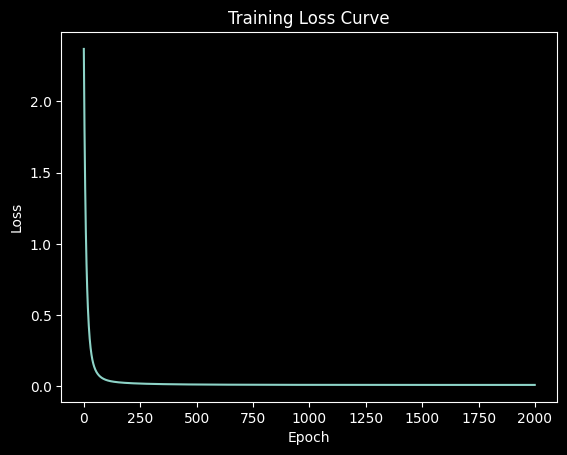

In [12]:
# Affichage des paramètres trouvés par le modèle
# On utilise .detach().numpy() pour détacher les poids du graphe de calcul avant de les imprimer
print("Weights:", model.weight.detach().numpy())
print("Bias:", model.bias.detach().numpy())

# Visualisation de la courbe d'erreur pour vérifier qu'elle "écrase" bien vers zéro
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()